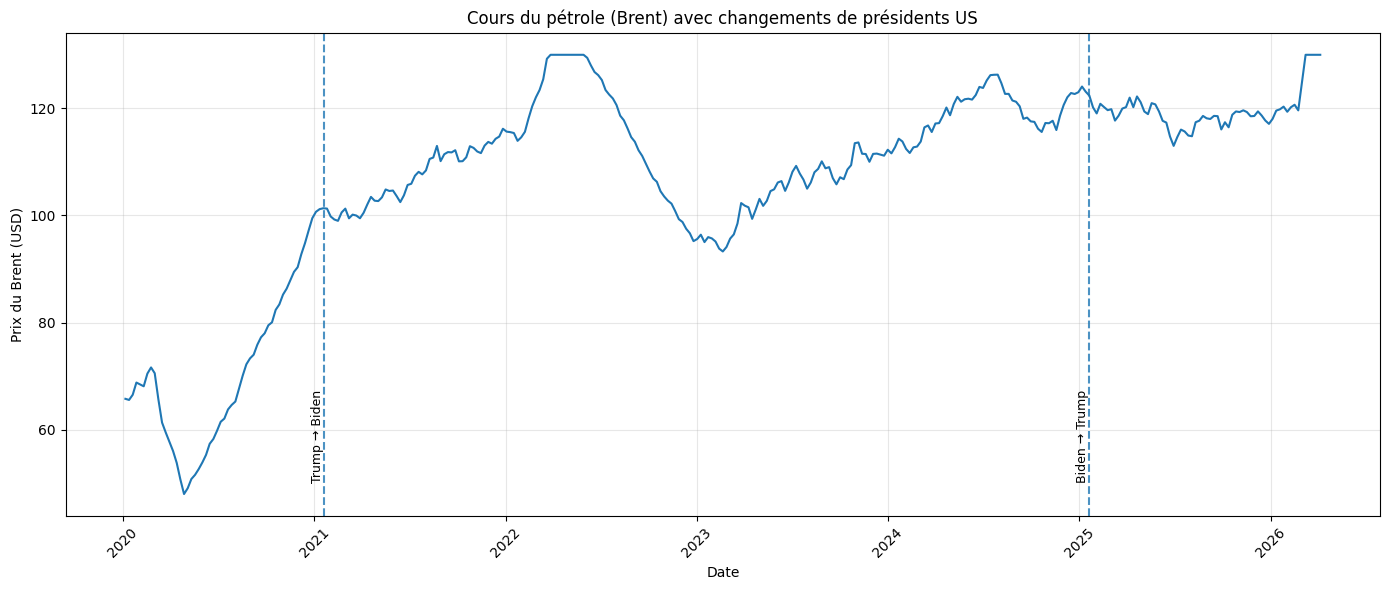

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Charger les données
df = pd.read_csv("global_fuel_prices_2020_2026.csv")
df["date"] = pd.to_datetime(df["date"])

# Filtrer États-Unis
us = df[df["country"] == "United States"].copy()
us = us.sort_values("date")

# Moyenne par date
oil = us.groupby("date", as_index=False)[["brent_crude_usd"]].mean()

# Définir les bornes des données
data_start = oil["date"].min()
data_end = oil["date"].max()

# Création du graphique
plt.figure(figsize=(14, 6))
plt.plot(oil["date"], oil["brent_crude_usd"])

plt.title("Cours du pétrole (Brent) avec changements de présidents US")
plt.xlabel("Date")
plt.ylabel("Prix du Brent (USD)")
plt.grid(True, alpha=0.3)

# Dates de transition présidentielle
transitions = [
    (pd.Timestamp("2021-01-20"), "Trump → Biden"),
    (pd.Timestamp("2025-01-20"), "Biden → Trump"),
]

# Ajouter lignes verticales
for date, label in transitions:
    if data_start <= date <= data_end:
        plt.axvline(date, linestyle="--", alpha=0.8)
        plt.text(
            date,
            oil["brent_crude_usd"].min() + 2,
            label,
            rotation=90,
            va="bottom",
            ha="right",
            fontsize=9
        )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

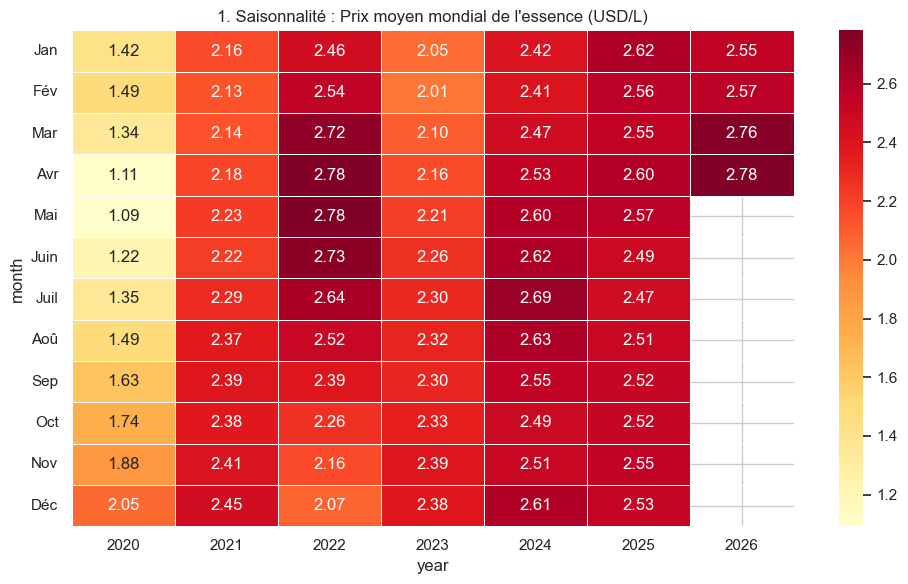

In [4]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
monthly_avg = df.pivot_table(index='month', columns='year', values='petrol_usd_liter', aggfunc='mean')
sns.heatmap(monthly_avg, cmap='YlOrRd', annot=True, fmt=".2f", linewidths=.5)
plt.title('1. Saisonnalité : Prix moyen mondial de l\'essence (USD/L)')
plt.yticks(ticks=np.arange(0.5, 12.5, 1), labels=['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc'], rotation=0)
plt.tight_layout()
plt.show()